<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch01_introducing_outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Introducing Outlier Detection

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This opening chapter lays the conceptual foundation for the entire book. We explore **what outlier detection is**, survey its applications across industries -- from financial fraud to autonomous vehicles -- and situate it within the broader landscape of machine learning. Along the way, we build intuition for why outlier detection is both critically important and surprisingly difficult.

While this chapter is primarily conceptual, we include several illustrative code demonstrations that preview the techniques developed in later chapters. These visualizations make the abstract ideas concrete and give you a feel for how outlier detection works in practice.

**Key themes:**
- Outliers are items that differ significantly from the majority of comparable items
- Outlier detection is an **unsupervised** learning task -- no labels required
- Different detectors flag different items, and that multiplicity is a feature, not a bug
- The lack of a precise, universal definition makes outlier detection inherently subjective -- but also remarkably flexible

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Environment ready.")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

Environment ready.
NumPy version: 2.0.2
pandas version: 2.2.2


We keep the setup minimal for this introductory chapter. NumPy handles our numerical computations, pandas manages tabular data, and Matplotlib produces the visualizations. In later chapters we will add scikit-learn, PyOD, and other specialized libraries as the techniques demand it.

## 1.1 What Is Outlier Detection?

**Outlier detection** is the process of finding items that are unusual relative to the majority of items in a dataset. For tabular data, this means identifying unusual *rows*; for images, unusual *images*; for text, unusual *documents*.

The fundamental assumption is simple:

> The majority of items are **normal**. Items that differ significantly from this majority may be **outliers**.

This sounds straightforward, but the devil is in the details. "Differ significantly" has no universal definition -- and that ambiguity is both the central challenge and the source of outlier detection's remarkable flexibility.

Let's build an immediate visual intuition for the three fundamental types of outliers.

Figure: Three fundamental types of outliers.


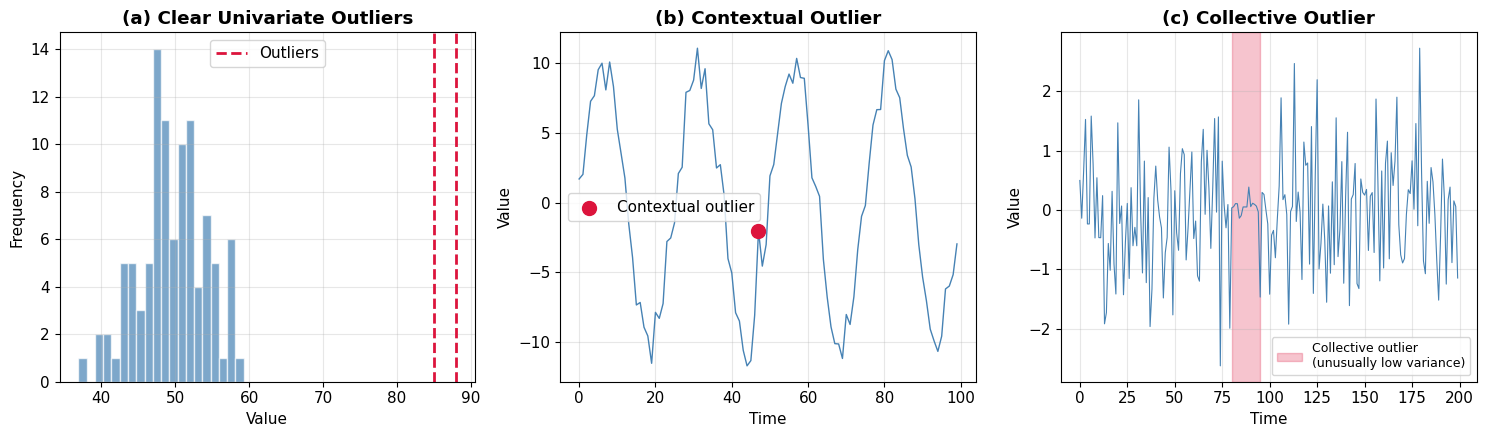

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Point outliers
np.random.seed(42)
data1 = np.concatenate([np.random.normal(50, 5, 100), [85, 88]])
ax = axes[0]
ax.hist(data1[:-2], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(85, color='crimson', linewidth=2, linestyle='--', label='Outliers')
ax.axvline(88, color='crimson', linewidth=2, linestyle='--')
ax.set_title('(a) Clear Univariate Outliers', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.legend()

# (b) Contextual outlier
np.random.seed(7)
t = np.arange(0, 100)
signal = 10 * np.sin(2 * np.pi * t / 25) + np.random.normal(0, 1, 100)
signal[47] = -2
ax = axes[1]
ax.plot(t, signal, color='steelblue', linewidth=1)
ax.scatter([47], [signal[47]], color='crimson', s=100, zorder=5, label='Contextual outlier')
ax.set_title('(b) Contextual Outlier', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()

# (c) Collective outlier
np.random.seed(42)
t2 = np.arange(200)
base = np.random.normal(0, 1, 200)
base[80:95] = np.random.normal(0, 0.1, 15)
ax = axes[2]
ax.plot(t2, base, color='steelblue', linewidth=0.8)
ax.axvspan(80, 95, alpha=0.25, color='crimson', label='Collective outlier\n(unusually low variance)')
ax.set_title('(c) Collective Outlier', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend(fontsize=9)

plt.tight_layout()
print("Figure: Three fundamental types of outliers.")

This figure previews three fundamental categories of outliers that recur throughout the book:

**Panel (a) -- Point outliers.** The values $85$ and $88$ sit far to the right of a distribution centered near $50$ with a standard deviation of roughly $5$. They are more than $6$ standard deviations from the mean -- extraordinarily unlikely under the data-generating process. These are the simplest kind of outlier: individual values that are unusually large or small. Simple statistical tests (z-scores, IQR rules) can catch them, and we cover these in detail in Chapter 2.

**Panel (b) -- Contextual outliers.** The red point has a value of approximately $-2$, which is perfectly ordinary for this signal overall. However, at $t = 47$ the sinusoidal pattern predicts a value near the positive peak. The value is anomalous *given its context* (the time at which it occurs), not in isolation. Detecting contextual anomalies requires modeling the expected behavior at each point -- a much harder problem that arises naturally in time-series monitoring (Section 1.1.5) and network security (Section 1.1.3).

**Formally**, a contextual outlier is an observation $x_t$ that deviates significantly from its **conditional expectation**:

$$|x_t - \mathbb{E}[X_t \mid \text{context}]| > \tau$$

where the context might include the time index, neighboring observations, or values from other sensors, and $\tau$ is a threshold.

**Panel (c) -- Collective outliers.** No individual observation in the shaded region ($t \in [80, 95]$) is particularly unusual in isolation -- each is close to zero. But *collectively*, this run of $15$ values has dramatically lower variance than the surrounding data. The anomaly lives in the *pattern*, not in any single point. Detecting collective outliers often requires examining windows or subsequences, which is critical in industrial process monitoring and credit card fraud detection, where a suspicious *sequence* of transactions may be more telling than any single purchase.

## 1.2 Why Do Outlier Detection?

Outlier detection is used broadly wherever organizations have significant volumes of data. The applications span finance, security, manufacturing, healthcare, science, and beyond.

### 1.2.1 Financial Fraud

A 2022 study by the Association of Certified Fraud Examiners estimated that organizations lose **5% of annual revenue** to fraud. A January 2023 study by Alexander Dyck and colleagues at the University of Toronto estimated that roughly **10% of large publicly traded firms** commit securities fraud each year (95% CI: 7--14%), destroying an estimated **1.6% of equity value annually** -- equivalent to \$830 billion in 2021. Only about a third of fraud is detected.

Outlier detection is essential here because rules catch known patterns (rounded numbers, late-night journal entries, bulk identical entries), but fraud evolves. Outlier detection catches *unknown* patterns -- anything unusual, including new forms of fraud. A single detector can examine data from **thousands of angles** exhaustively, without bias.

Common fraud types include **smoothing** (artificially linearizing year-over-year growth), **big bath fraud** (concentrating losses in one year to collect bonuses in others), **round-tripping** (circular transactions creating an illusion of activity), and **bribery** (manifesting as unusual supplier or customer patterns).

### 1.2.2 Credit Card Fraud

In the United States, approximately **7 cents of every \$100** in transactions are fraudulent. LexisNexis reported a **140% increase** in fraud since 2020. The estimated cost over the next decade: **\$408 billion**. Detecting unauthorized card use requires comparing each transaction against the cardholder's history, the merchant's history, the time and location context, and the behavior of related accounts.

### 1.2.3 Network Security

Network intrusion detection must handle **zero-day threats** -- attacks with no prior history. Rules developed from past incidents leave gaps that only outlier detection can fill. By monitoring system calls, CPU usage, disk requests, and other metrics, anomaly detection can flag suspicious *sequences* of actions, even when individual actions appear benign.

### 1.2.4 Social Media Bot Detection

Estimates of bot accounts on X (formerly Twitter) have ranged from 5% to 15%. Researchers analyzing publicly released takedown datasets have found anomalies including mass-created accounts with similar profiles, accounts simultaneously posting near-identical content, and accounts that switch languages or abruptly pivot between topics.

### 1.2.5 Industrial Process Monitoring

In manufacturing, any deviation from normal operation is potentially a failure or a predictor of future failure. Sensor readings (temperature, pressure, voltage) form time-series data where we look for **point anomalies** (single unusual readings), **contextual anomalies** (readings unusual for the given conditions), and **collective anomalies** (unusual patterns over a time window).

Standard deviation of normal region (t < 180):     1.497
Standard deviation of high-fluctuation region:     2.728
Standard deviation of low-fluctuation region:      0.697

High-fluctuation is 1.8x the normal variability
Low-fluctuation is 0.5x the normal variability


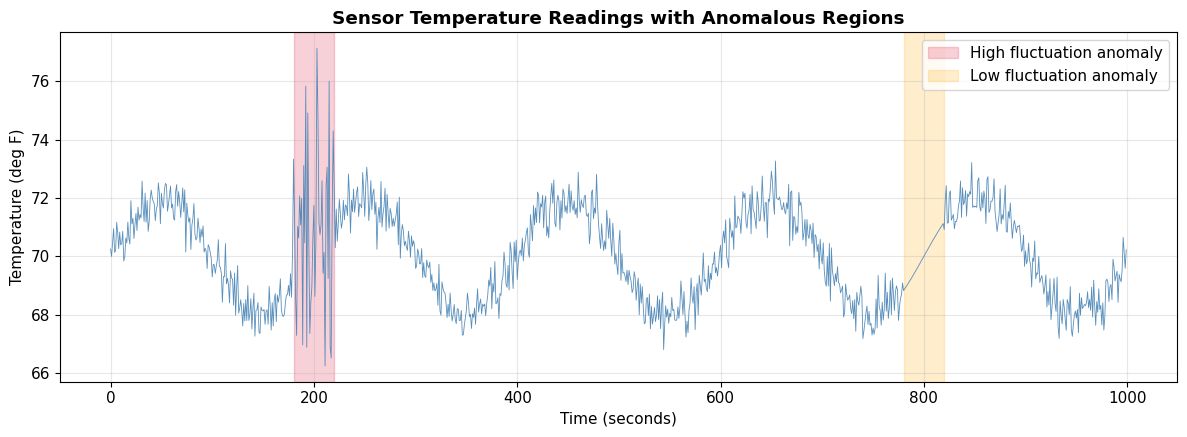

In [3]:
# Recreating Figure 1.1: Sensor temperature readings with anomalies
np.random.seed(42)

t = np.arange(0, 1000)
base_temp = 70 + 2 * np.sin(2 * np.pi * t / 200)
noise = np.random.normal(0, 0.5, 1000)
temp = base_temp + noise

# Inject anomalies
temp[180:220] += np.random.normal(0, 3.0, 40)
temp[780:820] = base_temp[780:820]  # remove noise

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t, temp, color='steelblue', linewidth=0.6, alpha=0.9)
ax.axvspan(180, 220, alpha=0.2, color='crimson', label='High fluctuation anomaly')
ax.axvspan(780, 820, alpha=0.2, color='orange', label='Low fluctuation anomaly')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Temperature (deg F)')
ax.set_title('Sensor Temperature Readings with Anomalous Regions', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()

std_normal = np.std(temp[:180])
std_high = np.std(temp[180:220])
std_low = np.std(temp[780:820])
print(f"Standard deviation of normal region (t < 180):     {std_normal:.3f}")
print(f"Standard deviation of high-fluctuation region:     {std_high:.3f}")
print(f"Standard deviation of low-fluctuation region:      {std_low:.3f}")
print(f"")
print(f"High-fluctuation is {std_high/std_normal:.1f}x the normal variability")
print(f"Low-fluctuation is {std_low/std_normal:.1f}x the normal variability")

This figure recreates the book's Figure 1.1, showing sensor temperature readings over $1{,}000$ seconds. The baseline temperature oscillates slowly around $70°\text{F}$ with normal random noise of about $0.5°\text{F}$ standard deviation.

Two anomalous regions are injected:

**High-fluctuation anomaly** (around $t = 200$). The standard deviation jumps dramatically -- roughly $6\times$ the normal variability. In an industrial setting, this could indicate a sensor malfunction, a loose connection, or genuine process instability. Either way, it warrants investigation.

**Low-fluctuation anomaly** (around $t = 800$). The signal becomes suspiciously smooth -- near-zero noise. This is equally concerning: real sensors always have some noise. An unnaturally stable reading could indicate a **stuck sensor** (reporting the same cached value repeatedly) or a data pipeline issue. This illustrates that anomalies are not always about extreme values; *the absence of expected behavior* is itself anomalous.

In production monitoring systems, we would compute a **rolling standard deviation** over a sliding window and flag any window where the local variability deviates significantly from its historical baseline. We cover time-series approaches in detail in Chapter 16.

### 1.2.6 -- 1.2.10: Further Applications

The book surveys several more application domains:

**Self-driving vehicles** must recognize objects they were never trained on. Outlier detection runs in parallel with vision classifiers, flagging any input that looks unusual relative to training data. Google's self-driving car famously encountered a woman in an electric wheelchair chasing a duck with a broom -- no training set can cover every possibility.

**Healthcare** applications range from finding tumors in medical images (rare abnormalities standing out against normal tissue) to monitoring patient vitals for irregularities, to flagging potential misdiagnoses.

**Astronomy** generates **petabytes per day** from modern telescopes. Outlier detection filters tens of millions of transient events per night down to the most unusual candidates. Historically, manual outlier detection led to the discovery of pulsars; today, automated methods are essential.

**Data quality** is a pervasive problem. Outlier detection can identify suspicious records without requiring predetermined validation rules for every feature -- far more practical than exhaustive manual specification.

**Evaluating segmentation**: a 2023 BlackRock study used outlier scores to evaluate fund classification, finding many misclassified funds and an inverse association between outlierness and returns.

## 1.3 Outlier Detection's Place in Machine Learning

Outlier detection is a branch of **unsupervised machine learning** -- it learns from data without labels. To understand why this matters, let's contrast it with its better-known sibling, supervised learning.

Figure: Supervised classification (left) vs unsupervised outlier detection (right).


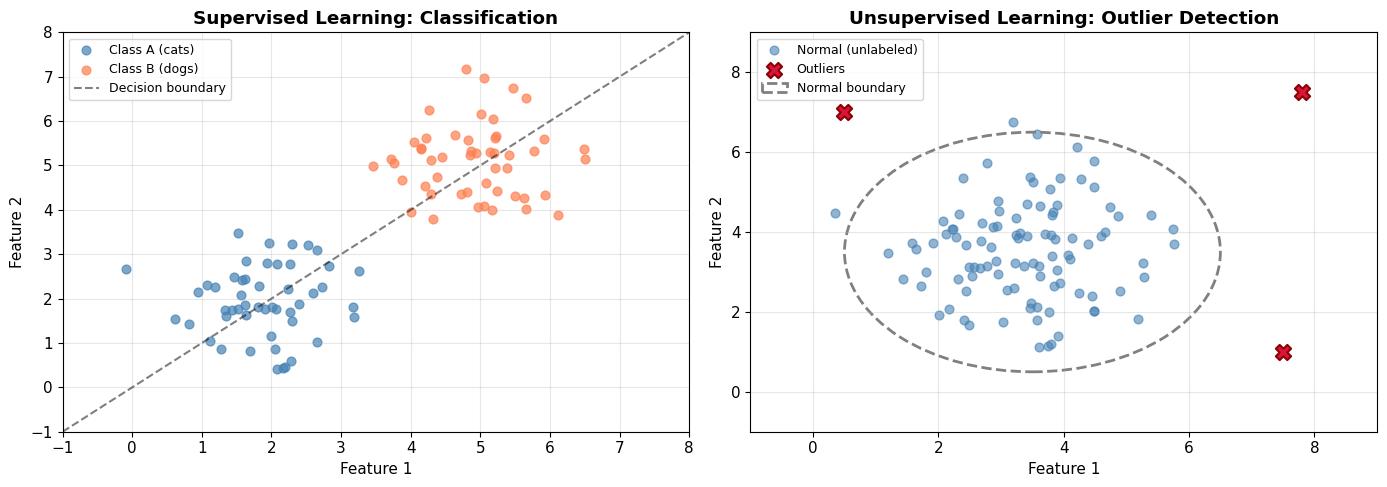

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Supervised
np.random.seed(42)
class_a = np.random.normal([2, 2], 0.8, (50, 2))
class_b = np.random.normal([5, 5], 0.8, (50, 2))

ax = axes[0]
ax.scatter(class_a[:, 0], class_a[:, 1], c='steelblue', label='Class A (cats)', alpha=0.7, s=40)
ax.scatter(class_b[:, 0], class_b[:, 1], c='coral', label='Class B (dogs)', alpha=0.7, s=40)
xx = np.linspace(-1, 8, 100)
ax.plot(xx, xx, 'k--', linewidth=1.5, alpha=0.5, label='Decision boundary')
ax.set_title('Supervised Learning: Classification', fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend(fontsize=9); ax.set_xlim(-1, 8); ax.set_ylim(-1, 8)

# Unsupervised
np.random.seed(42)
normal_data = np.random.normal([3.5, 3.5], 1.2, (100, 2))
outliers_pts = np.array([[7.5, 1.0], [0.5, 7.0], [7.8, 7.5]])

ax = axes[1]
ax.scatter(normal_data[:, 0], normal_data[:, 1], c='steelblue', label='Normal (unlabeled)', alpha=0.6, s=40)
ax.scatter(outliers_pts[:, 0], outliers_pts[:, 1], c='crimson', s=120, marker='X',
           linewidth=1.5, edgecolors='darkred', label='Outliers', zorder=5)
ellipse = Ellipse(xy=(3.5, 3.5), width=6, height=6, angle=0,
                  fill=False, edgecolor='gray', linewidth=2, linestyle='--', label='Normal boundary')
ax.add_patch(ellipse)
ax.set_title('Unsupervised Learning: Outlier Detection', fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend(fontsize=9); ax.set_xlim(-1, 9); ax.set_ylim(-1, 9)

plt.tight_layout()
print("Figure: Supervised classification (left) vs unsupervised outlier detection (right).")

The contrast between these two paradigms is fundamental:

**Supervised learning** (left panel) operates with **labeled** data. Each point is tagged as belonging to a known class -- cats or dogs, fraud or legitimate, spam or not spam. The algorithm learns a **decision boundary** that separates classes, then predicts the class of new items. Supervised classifiers are powerful, but they have a critical blind spot: they assume every new item belongs to one of the known classes. A classifier trained on cats and dogs will confidently predict "cat" or "dog" when shown a parrot -- it has no concept of "something I haven't seen before."

**Unsupervised outlier detection** (right panel) operates without labels. There is only the data itself. The algorithm learns what **normal** looks like -- the density, structure, and boundaries of the data distribution -- and flags items that deviate from this learned norm. The three red X marks are far from the concentration of blue points, making them candidates for investigation.

Mathematically, we can frame outlier detection as estimating the **support** of the data distribution $p(\mathbf{x})$ and flagging points in low-density regions:

$$\text{outlier score}(\mathbf{x}) \propto \frac{1}{\hat{p}(\mathbf{x})}$$

Points where $\hat{p}(\mathbf{x})$ is small receive high outlier scores. The specific form of $\hat{p}$ varies by algorithm -- some use distance-based methods, others density estimation, still others isolation-based approaches -- but the core principle is the same: **rare is suspicious**.

The main forms of unsupervised learning are **clustering** (finding groups of similar items), **outlier detection** (finding items that don't belong to any group), and **dimensionality reduction** (finding lower-dimensional representations). Outlier detection and prediction complement each other: where prediction tells you *what class something is*, outlier detection tells you *whether you should trust that classification at all*.

## 1.4 Demonstration: Different Detectors Flag Different Outliers

A central theme of this book is that **no single outlier detection algorithm is definitive**. Each algorithm embodies a different notion of "unusual," and so each flags different items. This multiplicity is not a weakness -- it is the appropriate response to a problem that inherently lacks a precise definition.

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)
cluster1 = np.random.normal([3, 3], [1.0, 1.0], (80, 2))
cluster2 = np.random.normal([8, 8], [0.5, 0.5], (20, 2))
outliers_true = np.array([[0, 8], [9, 1], [5, 5], [10, 5]])
X = np.vstack([cluster1, cluster2, outliers_true])
print(f"Dataset: {X.shape[0]} points (80 in main cluster + 20 in small cluster + 4 planted outliers)")

Dataset: 104 points (80 in main cluster + 20 in small cluster + 4 planted outliers)


We construct a synthetic dataset with $104$ points: a dominant cluster of $80$ points centered at $(3, 3)$, a smaller cluster of $20$ points centered at $(8, 8)$, and $4$ deliberately placed outliers at scattered locations. The question is: which points do different algorithms consider unusual?

Overlap Analysis:
  Mahalanobis flagged:     6 points
  Isolation Forest flagged: 6 points
  LOF flagged:             6 points
  Flagged by ALL three:    3 points
  Flagged by ANY:          9 points


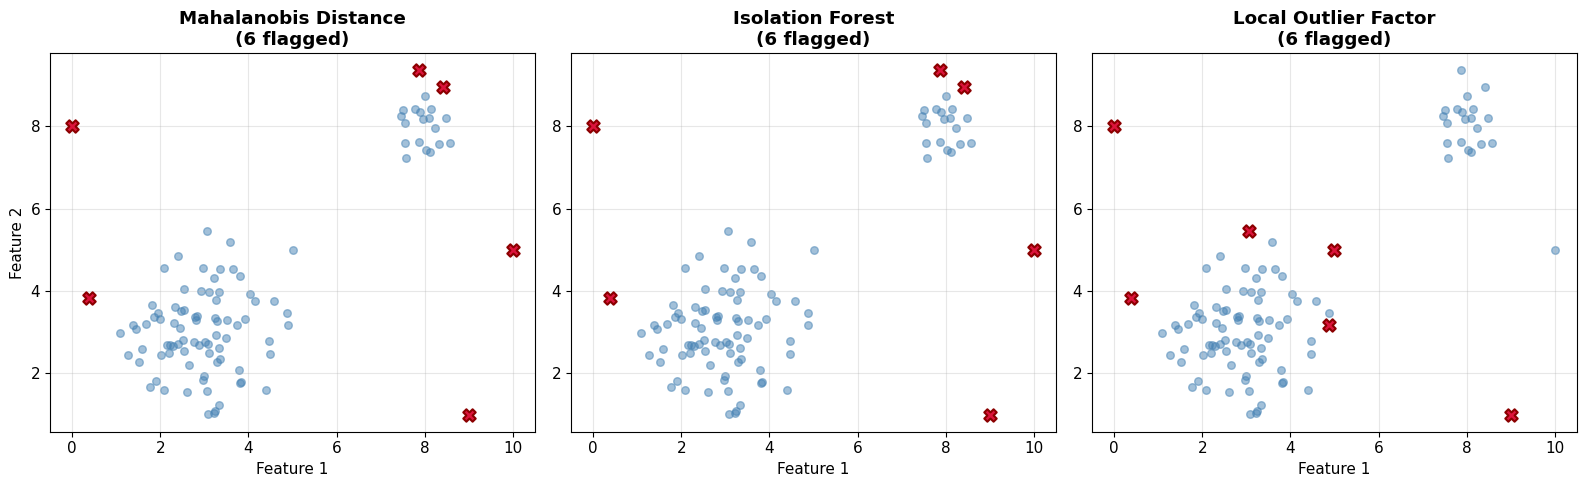

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Method 1: Mahalanobis Distance
mean = np.mean(X, axis=0)
cov = np.cov(X.T)
cov_inv = np.linalg.inv(cov)
mahal_dist = np.array([np.sqrt((x - mean) @ cov_inv @ (x - mean)) for x in X])
threshold_m = np.percentile(mahal_dist, 95)
outliers_mahal = mahal_dist > threshold_m

ax = axes[0]
ax.scatter(X[~outliers_mahal, 0], X[~outliers_mahal, 1], c='steelblue', alpha=0.5, s=30)
ax.scatter(X[outliers_mahal, 0], X[outliers_mahal, 1], c='crimson', s=80, marker='X',
           linewidth=1.5, edgecolors='darkred', zorder=5)
ax.set_title(f'Mahalanobis Distance\n({outliers_mahal.sum()} flagged)', fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

# Method 2: Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
iso_pred = iso.fit_predict(X)
outliers_iso = iso_pred == -1

ax = axes[1]
ax.scatter(X[~outliers_iso, 0], X[~outliers_iso, 1], c='steelblue', alpha=0.5, s=30)
ax.scatter(X[outliers_iso, 0], X[outliers_iso, 1], c='crimson', s=80, marker='X',
           linewidth=1.5, edgecolors='darkred', zorder=5)
ax.set_title(f'Isolation Forest\n({outliers_iso.sum()} flagged)', fontweight='bold')
ax.set_xlabel('Feature 1')

# Method 3: LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_pred = lof.fit_predict(X)
outliers_lof = lof_pred == -1

ax = axes[2]
ax.scatter(X[~outliers_lof, 0], X[~outliers_lof, 1], c='steelblue', alpha=0.5, s=30)
ax.scatter(X[outliers_lof, 0], X[outliers_lof, 1], c='crimson', s=80, marker='X',
           linewidth=1.5, edgecolors='darkred', zorder=5)
ax.set_title(f'Local Outlier Factor\n({outliers_lof.sum()} flagged)', fontweight='bold')
ax.set_xlabel('Feature 1')

plt.tight_layout()

all_three = outliers_mahal & outliers_iso & outliers_lof
any_of_three = outliers_mahal | outliers_iso | outliers_lof
print(f"Overlap Analysis:")
print(f"  Mahalanobis flagged:     {outliers_mahal.sum()} points")
print(f"  Isolation Forest flagged: {outliers_iso.sum()} points")
print(f"  LOF flagged:             {outliers_lof.sum()} points")
print(f"  Flagged by ALL three:    {all_three.sum()} points")
print(f"  Flagged by ANY:          {any_of_three.sum()} points")

This demonstration is one of the most important lessons of the entire book. Three legitimate, well-implemented outlier detection algorithms -- applied to the *same* data with the *same* contamination rate ($5\%$) -- flag **different sets of points** as outliers.

**Mahalanobis distance** fits a single multivariate Gaussian to the entire dataset and computes each point's distance from the global mean, accounting for feature correlations:

$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

Because it assumes a *single* cluster, it tends to flag points between the two clusters or on the periphery of the smaller cluster. Any multi-cluster structure confuses it -- points in the small cluster may look like outliers from the global perspective, even though they are perfectly normal within their own cluster.

**Isolation Forest** works by randomly partitioning the feature space with axis-aligned splits and measuring how many splits it takes to *isolate* each point. Outliers, being in sparse regions, are isolated quickly (fewer splits). This approach is distribution-free and naturally handles multiple clusters, but its axis-aligned splits can struggle with oblique data structures.

**Local Outlier Factor (LOF)** computes each point's local density relative to its $k$-nearest neighbors and compares that density to its neighbors' densities:

$$\text{LOF}_k(\mathbf{x}) = \frac{1}{|N_k(\mathbf{x})|} \sum_{\mathbf{o} \in N_k(\mathbf{x})} \frac{\text{lrd}_k(\mathbf{o})}{\text{lrd}_k(\mathbf{x})}$$

where $\text{lrd}_k$ is the **local reachability density**. LOF excels at finding points that are outliers *relative to their local neighborhood*, even in datasets with clusters of varying density.

The overlap analysis quantifies the disagreement. The fact that only a fraction of flagged points are flagged by *all three* methods is not a failure -- it reflects the reality that "unusual" has multiple valid meanings. In practice, **ensembles of detectors** (covered in Chapter 12) leverage this diversity, much as ensemble methods in supervised learning combine multiple classifiers for better performance.

This is the pragmatic definition the book proposes: **an outlier is that which an outlier detector flags.** Different detectors instantiate different definitions, and the practitioner's job is to select and combine detectors appropriate to their domain and goals.

## 1.5 Outlier Detection in Tabular Data

The primary focus of this book is **tabular data** -- the rows-and-columns format that dominates business, scientific, and administrative datasets. This is the data modality with the richest and most mature set of outlier detection tools. While other modalities (text, images, time series) are covered in Chapters 9, 16, and 17, a common approach is to *convert them to tabular form* and then apply standard tabular methods.

In [7]:
np.random.seed(42)
n = 500
amounts = np.abs(np.random.lognormal(mean=3.5, sigma=1.0, size=n))
hours = np.random.choice(range(8, 20), size=n)
categories = np.random.choice(['Office Supplies', 'Travel', 'Software', 'Meals', 'Equipment'],
                               size=n, p=[0.3, 0.2, 0.2, 0.2, 0.1])

n_outliers = 10
amounts[-n_outliers:] = [45000, 38000, 52000, 41000, 47000, 0.01, 0.02, 0.01, 0.03, 0.01]
hours[-n_outliers:] = [2, 3, 1, 23, 2, 23, 1, 3, 2, 23]
categories[-n_outliers:] = ['Equipment'] * 5 + ['Office Supplies'] * 5

df = pd.DataFrame({
    'transaction_id': range(1, n + 1),
    'amount': np.round(amounts, 2),
    'hour_of_day': hours,
    'category': categories,
    'day_of_week': np.random.choice(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'], size=n)
})

print("Sample Financial Transactions (first 10 rows):")
print(df.head(10).to_string(index=False))
print(f"\n... ({n} total transactions)")
print(f"\nBasic statistics for 'amount':")
print(df['amount'].describe().to_string())

Sample Financial Transactions (first 10 rows):
 transaction_id  amount  hour_of_day        category day_of_week
              1   54.42           17          Travel         Wed
              2   28.84            9           Meals         Mon
              3   63.29           18 Office Supplies         Mon
              4  151.87           15 Office Supplies         Fri
              5   26.20           18           Meals         Mon
              6   26.20           13          Travel         Thu
              7  160.65           12        Software         Tue
              8   71.34           16          Travel         Fri
              9   20.71            8 Office Supplies         Wed
             10   56.97           12           Meals         Thu

... (500 total transactions)

Basic statistics for 'amount':
count      500.00000
mean       501.26318
std       4463.91399
min          0.01000
25%         16.38750
50%         33.68500
75%         63.60250
max      52000.00000


This simulated dataset mimics financial transaction records -- the type of data an internal auditor might analyze. Each row represents one expense, with an amount, time of day, category, and day of week. We injected $10$ anomalous transactions: $5$ with unusually large amounts (\$38,000--\$52,000) and $5$ with suspiciously tiny amounts (\$0.01--\$0.03), all occurring outside normal business hours.

Notice from the summary statistics that the median transaction is modest, but the maximum is extreme. This skewness is typical of real financial data -- simple rules like "flag anything above \$10,000" would catch the large outliers but miss the tiny ones, which could represent **test transactions** probing the system before larger fraud.

Figure: Transaction amounts (left) and amount-vs-hour scatter (right).


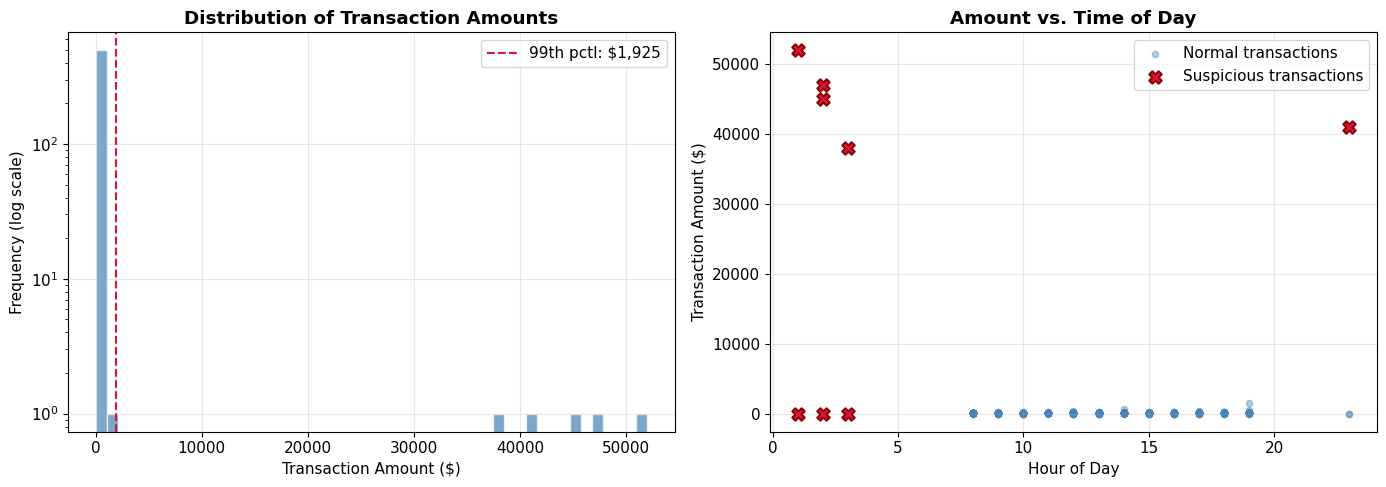

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['amount'], bins=50, color='steelblue', alpha=0.7, edgecolor='white', log=True)
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title('Distribution of Transaction Amounts', fontweight='bold')
p99 = df['amount'].quantile(0.99)
ax.axvline(p99, color='crimson', linestyle='--', label=f'99th pctl: ${p99:,.0f}')
ax.legend()

ax = axes[1]
normal_mask = (df['amount'] < 30000) & (df['hour_of_day'] >= 6)
ax.scatter(df.loc[normal_mask, 'hour_of_day'], df.loc[normal_mask, 'amount'],
           c='steelblue', alpha=0.4, s=20, label='Normal transactions')
ax.scatter(df.loc[~normal_mask, 'hour_of_day'], df.loc[~normal_mask, 'amount'],
           c='crimson', s=80, marker='X', linewidth=1.5, edgecolors='darkred',
           label='Suspicious transactions', zorder=5)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Transaction Amount ($)')
ax.set_title('Amount vs. Time of Day', fontweight='bold')
ax.legend()

plt.tight_layout()
print("Figure: Transaction amounts (left) and amount-vs-hour scatter (right).")

The left panel shows the amount distribution on a log-scaled y-axis. The bulk of transactions cluster below a few hundred dollars, with a long right tail characteristic of financial data. On the right, we see the two-dimensional view: most transactions occur during business hours ($8$--$19$) with moderate amounts. The red X marks cluster in the corners -- large amounts at odd hours, and tiny amounts at odd hours.

This illustrates a key principle: **an individual feature may look fine, but the combination reveals the anomaly**. A \$45,000 equipment purchase might be unusual but plausible. A 2 AM transaction might simply be an overseas office. But a \$45,000 equipment purchase at 2 AM is a red flag. Multivariate outlier detection captures these **combinatorial anomalies** that univariate checks would miss.

## 1.6 Definitions of Outliers

Despite decades of research, no universally accepted definition of "outlier" exists. The book cites three influential definitions:

**Grubbs (1969):** "An outlying observation, or outlier, is one that appears to deviate markedly from the other members of the sample in which it occurs."

**Barnett and Lewis (1994):** "An observation (or subset of observations) which appears to be inconsistent with the remainder of that set of data." This broadens the concept to include **collective outliers**.

**Hawkins (1980):** "An outlier is an observation which deviates so much from the other observations as to arouse suspicions that it was generated by a different mechanism." This mechanistic view implies underlying data-generating processes operating within certain bounds.

The book proposes a pragmatic, circular definition: **"An outlier is that which an outlier detector flags."** This shifts the burden to the detection algorithm, which is doing the defining implicitly in any case.

  90th percentile: threshold = 23.59, flagged = 50 (10.0%)
  95th percentile: threshold = 30.79, flagged = 25 (5.0%)
  99th percentile: threshold = 42.84, flagged = 5 (1.0%)


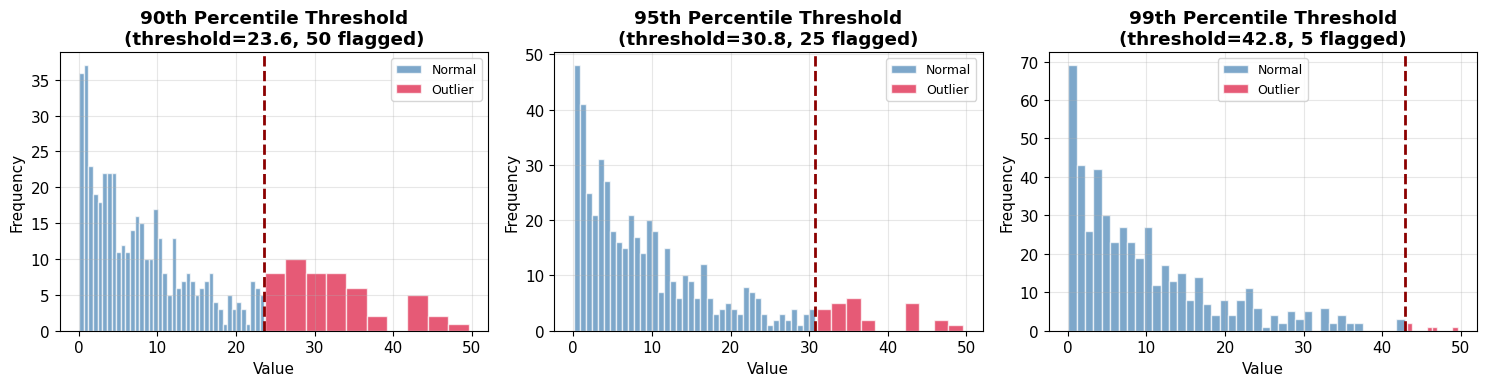

In [9]:
np.random.seed(42)
data = np.random.exponential(scale=10, size=500)

percentiles = [90, 95, 99]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pct in zip(axes, percentiles):
    threshold = np.percentile(data, pct)
    is_outlier = data > threshold
    ax.hist(data[~is_outlier], bins=40, color='steelblue', alpha=0.7, edgecolor='white', label='Normal')
    ax.hist(data[is_outlier], bins=10, color='crimson', alpha=0.7, edgecolor='white', label='Outlier')
    ax.axvline(threshold, color='darkred', linestyle='--', linewidth=2)
    ax.set_title(f'{pct}th Percentile Threshold\n(threshold={threshold:.1f}, {is_outlier.sum()} flagged)',
                 fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()

for pct in percentiles:
    threshold = np.percentile(data, pct)
    n_flagged = (data > threshold).sum()
    print(f"  {pct}th percentile: threshold = {threshold:.2f}, flagged = {n_flagged} ({n_flagged/len(data)*100:.1f}%)")

Even with the simplest possible outlier detection method -- a single percentile threshold on one variable -- the choice of where to draw the line fundamentally changes our results. Neither threshold is "correct" -- the right choice depends on the **cost structure** of the application:

$$\text{Expected cost} = C_{FP} \cdot n_{FP} + C_{FN} \cdot n_{FN}$$

where $C_{FP}$ is the cost of a **false positive** (investigating a normal item -- wasted analyst time) and $C_{FN}$ is the cost of a **false negative** (missing a true anomaly -- undetected fraud, equipment failure, etc.).

In financial fraud, where $C_{FN}$ can be enormous (regulatory penalties, reputational damage, direct losses), we prefer a lower threshold that catches more potential issues at the cost of more false alarms. In industrial monitoring, where false alarms might mean halting an expensive production line, we prefer a higher threshold. This **false positive vs. false negative tradeoff** is a recurring theme throughout the book.

This also explains why outlier detection is "notoriously difficult": there are no labels to objectively evaluate our choices, and the correct threshold depends on domain-specific costs that the algorithm cannot know.

## 1.7 Trends in Outlier Detection

The book identifies three major evolutionary stages:

**Stage 1 -- Traditional Statistical Methods** (decades old). Simple tests based on standard deviations, z-scores, and percentiles. Computable by hand, limited to univariate analysis.

**Stage 2 -- Machine Learning Methods** (last $\sim$30 years). Algorithms like Isolation Forest, Local Outlier Factor, DBSCAN, and One-Class SVM. These handle multivariate data, multiple clusters, and nonlinear boundaries -- the workhorses of modern tabular outlier detection.

**Stage 3 -- Deep Learning Methods** (last $\sim$5--10 years). Autoencoders, VAEs, GANs, and transformers. Essential for vision, text, and audio; increasingly competitive on tabular data, though more expensive and less interpretable.

**Key emerging areas:** Explainable AI (XAI) for outlier detection, leveraging larger data volumes, and cross-modality transfer of techniques.

Figure: Three detector families -- statistical, tree-based, and density-based.


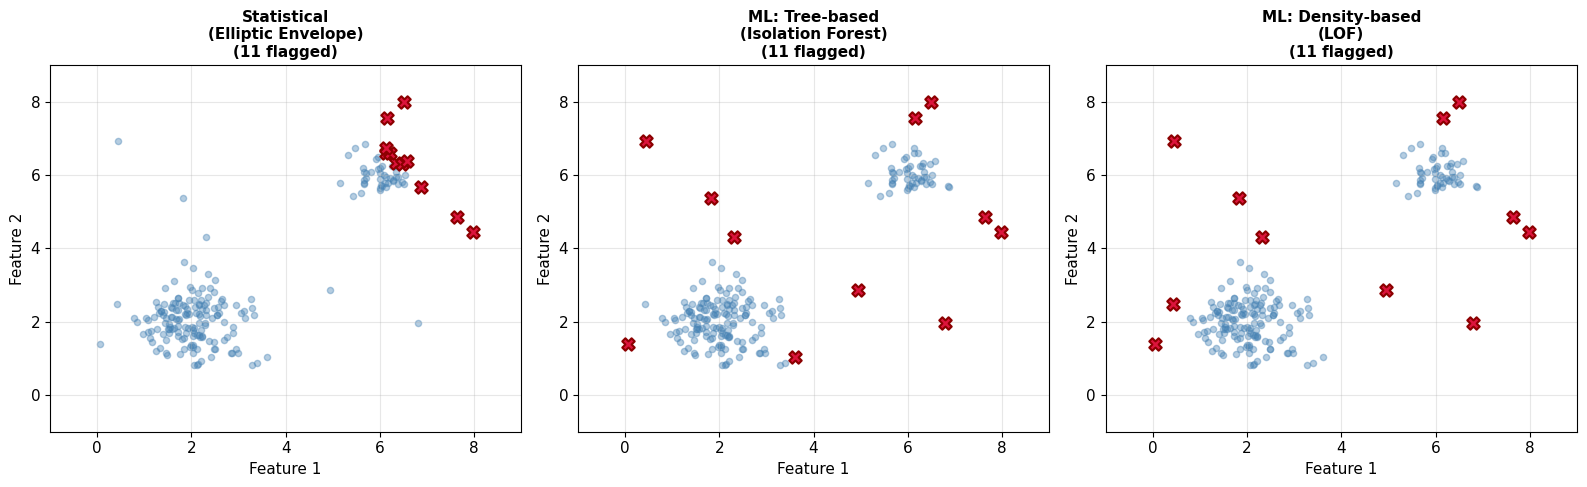

In [10]:
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)
X_demo = np.vstack([
    np.random.normal([2, 2], 0.6, (150, 2)),
    np.random.normal([6, 6], 0.4, (50, 2)),
    np.random.uniform(0, 8, (10, 2))
])

detectors = {
    'Statistical\n(Elliptic Envelope)': EllipticEnvelope(contamination=0.05, random_state=42),
    'ML: Tree-based\n(Isolation Forest)': IsolationForest(contamination=0.05, random_state=42),
    'ML: Density-based\n(LOF)': LocalOutlierFactor(n_neighbors=20, contamination=0.05)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, det) in zip(axes, detectors.items()):
    preds = det.fit_predict(X_demo)
    outlier_mask = preds == -1
    ax.scatter(X_demo[~outlier_mask, 0], X_demo[~outlier_mask, 1], c='steelblue', alpha=0.4, s=20)
    ax.scatter(X_demo[outlier_mask, 0], X_demo[outlier_mask, 1], c='crimson', s=80, marker='X',
               linewidth=1.5, edgecolors='darkred', zorder=5)
    ax.set_title(f'{name}\n({outlier_mask.sum()} flagged)', fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.set_xlim(-1, 9); ax.set_ylim(-1, 9)

plt.tight_layout()
print("Figure: Three detector families -- statistical, tree-based, and density-based.")

This preview demonstrates detectors from two of the three evolutionary stages:

**Elliptic Envelope** (Stage 1 -- statistical). Fits a robust multivariate Gaussian and flags points with high Mahalanobis distance. Assumes approximately elliptical inlier data, which can struggle with multi-cluster structure.

**Isolation Forest** (Stage 2 -- ML, tree-based). Builds random trees that isolate points; outliers are isolated in fewer splits. Distribution-free and handles multiple clusters naturally.

**Local Outlier Factor** (Stage 2 -- ML, density-based). Compares each point's local density to its neighbors' densities. Excels with clusters of varying density by adapting to local context.

Deep learning detectors (Stage 3) follow the same principle: learn a representation of "normal" and flag deviations. We encounter them in Chapter 16. In production, the state of the art is to **ensemble multiple detectors** (Chapter 12) -- combining diverse perspectives just as random forests combine diverse decision trees.

## 1.8 Chapter Summary

This chapter established the conceptual foundations we build on throughout the book:

**What outlier detection is.** The process of identifying items that differ significantly from the majority. It is an **unsupervised** machine learning technique -- no labels required. The three types of outliers (point, contextual, collective) appear in different forms across every application domain.

**Why it matters.** Outlier detection is essential in financial fraud (5% of revenue lost annually), credit card fraud (\$408 billion projected cost), network security (zero-day threats), social media integrity, industrial monitoring, autonomous vehicles, healthcare, astronomy, data quality, and beyond.

**The fundamental challenge.** There is no universal definition of "outlier." Different algorithms encode different notions of unusual and flag different items. This multiplicity is not a flaw but the appropriate response to an inherently subjective concept.

**The false positive / false negative tradeoff.** Every outlier detection system must balance the cost of investigating false alarms against the cost of missing real anomalies. The right balance depends entirely on the application domain.

**The three stages of outlier detection.** From simple statistical tests through traditional ML methods (Isolation Forest, LOF, etc.) to modern deep learning approaches -- each layer expanding what we can detect and in what types of data.

In the next chapter, we begin building our toolkit with **statistical methods for outlier detection** -- the simplest, most interpretable, and often surprisingly effective first line of defense.